# MediaPipe Pose — Video Analysis

Pipeline:
1. **Setup** — imports, video path, model path
2. **Inspect** — read the first frame and preview video metadata
3. **Detect (single frame)** — run MediaPipe Pose on the first full frame to verify detection
4. **Process (full video)** — run pose detection across every frame in VIDEO mode
5. **Save** — write annotated frames with landmark overlays to `output/annotated_frames/`

--------------------
# Setup cells

## Load individual video

In [1]:
# --- Imports ---
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.core.base_options import BaseOptions
from mediapipe.tasks.python.vision.pose_landmarker import (
    PoseLandmarker,
    PoseLandmarkerOptions,
)
from mediapipe.tasks.python.vision.core.vision_task_running_mode import VisionTaskRunningMode as RunningMode

# --- Paths ---
project_root = Path.cwd()
video_path = project_root / "raw" / "ref2.mp4"
model_path = project_root / "model" / "pose_landmarker_full.task"

if not video_path.exists():
    raise FileNotFoundError(f"Video not found: {video_path}")
if not model_path.exists():
    raise FileNotFoundError(f"Model not found: {model_path}")

print(f"Video : {video_path}")
print(f"Model : {model_path}")


Video : /Users/gdoan/code/ai-micro-learn/raw/ref2.mp4
Model : /Users/gdoan/code/ai-micro-learn/model/pose_landmarker_full.task


Frames     : 61
FPS        : 29.51
Resolution : 1080 x 1920


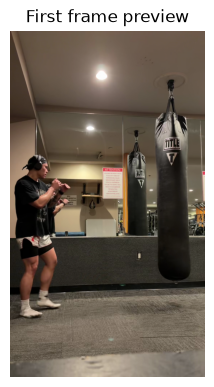

In [2]:
# Open the video and read basic metadata
cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {video_path}")

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps         = cap.get(cv2.CAP_PROP_FPS)
width       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Read the very first frame for inspection; BGR → RGB for matplotlib
ok, first_frame_bgr = cap.read()
cap.release()
if not ok:
    raise RuntimeError("Could not read the first frame from the video")

first_frame_rgb = cv2.cvtColor(first_frame_bgr, cv2.COLOR_BGR2RGB)

print(f"Frames     : {frame_count}")
print(f"FPS        : {fps:.2f}")
print(f"Resolution : {width} x {height}")

# Preview the first frame
plt.figure(figsize=(8, 4.5))
plt.imshow(first_frame_rgb)
plt.title("First frame preview")
plt.axis("off")
plt.show()

## Setup Spark Session

In [3]:
import os
from pyspark.sql import SparkSession
from delta.pip_utils import configure_spark_with_delta_pip

# Stabilize local Spark networking on macOS hostnames.
os.environ.setdefault("SPARK_LOCAL_HOSTNAME", "localhost")
os.environ.setdefault("SPARK_LOCAL_IP", "127.0.0.1")

# If a SparkSession already exists (without Delta jars), stop it first.
# Otherwise getOrCreate() can silently reuse a non-Delta session.
try:
    spark.stop()
except Exception:
    pass

builder = (
    SparkSession.builder
    .appName("OlistCDC")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
    .config("spark.sql.shuffle.partitions", 50)
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.autoBroadcastJoinThreshold", 10 * 1024 * 1024)
)

spark = configure_spark_with_delta_pip(builder).getOrCreate()
spark.sparkContext.setLogLevel("WARN")

# Quick sanity checks so failures surface early.
print("✅ SparkSession ready — Spark", spark.version)
print("   spark.sql.extensions:", spark.conf.get("spark.sql.extensions", "<unset>"))
print("   spark.sql.catalog.spark_catalog:", spark.conf.get("spark.sql.catalog.spark_catalog", "<unset>"))
print("   spark.jaars.packages:", spark.conf.get("spark.jars.packages", "<unset>"))


:: loading settings :: url = jar:file:/Users/gdoan/code/ai-micro-learn/.venv/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /Users/gdoan/.ivy2.5.2/cache
The jars for the packages stored in: /Users/gdoan/.ivy2.5.2/jars
io.delta#delta-spark_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-df60df98-5a28-43b6-927c-f3ac2f033aca;1.0
	confs: [default]
	found io.delta#delta-spark_2.13;4.0.0 in central
	found io.delta#delta-storage;4.0.0 in central
	found org.antlr#antlr4-runtime;4.13.1 in central
downloading https://repo1.maven.org/maven2/io/delta/delta-spark_2.13/4.0.0/delta-spark_2.13-4.0.0.jar ...
	[SUCCESSFUL ] io.delta#delta-spark_2.13;4.0.0!delta-spark_2.13.jar (309ms)
downloading https://repo1.maven.org/maven2/io/delta/delta-storage/4.0.0/delta-storage-4.0.0.jar ...
	[SUCCESSFUL ] io.delta#delta-storage;4.0.0!delta-storage.jar (75ms)
downloading https://repo1.mave

✅ SparkSession ready — Spark 4.0.0
   spark.sql.extensions: io.delta.sql.DeltaSparkSessionExtension
   spark.sql.catalog.spark_catalog: org.apache.spark.sql.delta.catalog.DeltaCatalog
   spark.jaars.packages: io.delta:delta-spark_2.13:4.0.0


----------------
# Bronze Processing

## Bronze Table Setup

In [4]:
from pyspark.sql.types import (
    DoubleType,
    IntegerType,
    LongType,
    StringType,
    StructField,
    StructType,
)

# Bronze schema: raw per-frame pose landmarks, unfiltered
# rep_id, frame_idx, timestamp_ms, landmark_id, landmark_name, x, y, z, visibility
BRONZE_SCHEMA = StructType([
    StructField("rep_id",        StringType(),  nullable=False),
    StructField("frame_idx",     IntegerType(), nullable=False),
    StructField("timestamp_ms",  LongType(),    nullable=False),
    StructField("landmark_id",   IntegerType(), nullable=False),
    StructField("landmark_name", StringType(),  nullable=False),
    StructField("x",             DoubleType(),  nullable=True),
    StructField("y",             DoubleType(),  nullable=True),
    StructField("z",             DoubleType(),  nullable=True),
    StructField("visibility",    DoubleType(),  nullable=True),
])

# MediaPipe Tasks API landmark names (33 landmarks, indices 0–32)
LANDMARK_NAMES = [
    "nose", "left_eye_inner", "left_eye", "left_eye_outer",
    "right_eye_inner", "right_eye", "right_eye_outer",
    "left_ear", "right_ear", "mouth_left", "mouth_right",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_pinky", "right_pinky",
    "left_index", "right_index", "left_thumb", "right_thumb",
    "left_hip", "right_hip", "left_knee", "right_knee",
    "left_ankle", "right_ankle", "left_heel", "right_heel",
    "left_foot_index", "right_foot_index",
]

BRONZE_LOCATION = str(project_root / "bronze" / "pose_landmarks")
BATCH_SIZE = 30          # flush to Delta every N frames

## Process Video Bronze

In [5]:
import uuid
from mediapipe.tasks.python.vision.pose_landmarker import PoseLandmarkerResult

VisionRunningMode = mp.tasks.vision.RunningMode
rep_id = str(uuid.uuid4())

options_video = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=str(model_path)),
    running_mode=VisionRunningMode.VIDEO,
)

all_results: list[PoseLandmarkerResult] = []
all_frames  = []
pending_rows: list[dict] = []
frames_written = 0

def flush_to_delta(rows: list[dict]) -> None:
    spark.createDataFrame(rows, schema=BRONZE_SCHEMA).write.format("delta").mode("append").save(BRONZE_LOCATION)

with PoseLandmarker.create_from_options(options_video) as landmarker:
    cap = cv2.VideoCapture(str(video_path))
    frame_idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image  = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        timestamp_ms = int(cap.get(cv2.CAP_PROP_POS_MSEC))
        result = landmarker.detect_for_video(mp_image, timestamp_ms)

        all_results.append(result)
        all_frames.append(frame_rgb)

        for pose_landmarks in result.pose_landmarks:
            for landmark_id, lm in enumerate(pose_landmarks):
                pending_rows.append({
                    "rep_id":        rep_id,
                    "frame_idx":     frame_idx,
                    "timestamp_ms":  timestamp_ms,
                    "landmark_id":   landmark_id,
                    "landmark_name": LANDMARK_NAMES[landmark_id],
                    "x":             float(lm.x),
                    "y":             float(lm.y),
                    "z":             float(lm.z),
                    "visibility":    float(lm.visibility) if lm.visibility is not None else None,
                })

        if len(pending_rows) >= BATCH_SIZE:
            flush_to_delta(pending_rows)
            frames_written += len(pending_rows)
            pending_rows.clear()

        frame_idx += 1

    cap.release()

# Flush any remaining rows
if pending_rows:
    flush_to_delta(pending_rows)
    frames_written += len(pending_rows)

print(f"Processed {len(all_results)} frames")
print(f"Frames with a detected person : {sum(1 for r in all_results if r.pose_landmarks)}")
print(f"Landmark rows written to Delta : {frames_written}")
print(f"Location : {BRONZE_LOCATION}")


I0000 00:00:1781738817.754305 49318333 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
I0000 00:00:1781738817.903578 49318333 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781738817.996775 49318341 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781738818.024766 49318348 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781738818.086734 49318340 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
26/06/17 19:27:03 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling

Processed 61 frames
Frames with a detected person : 61
Landmark rows written to Delta : 2013
Location : /Users/gdoan/code/ai-micro-learn/bronze/pose_landmarks


E0000 00:00:1781738890.709923 49318334 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-06-17T19:42:57.933736-04:00
=== Source Location Trace: === 
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
